# PV-BESS optimizer

Example Jupyter notebook for scheduling a PV-BESS system using the Pyomo optimization framework.
This jupyter notebook sets up the model, defines the variables, constraints, and objective function,
and then solves the optimization problem to determine the optimal charging and discharging schedule.

### Imports

In [1]:
# Import necessary libraries
from scheduler import get_schedule # Import the scheduler module which contains the Pyomo model and optimization logic
import matplotlib.pyplot as plt  # Import matplotlib for plotting results
import pandas as pd  # Import pandas for data handling

### Set the input parameters

In [2]:
p_limit = 8  # Maximum injection power limit
storage_capacity = 10
p_charge_max = 5
p_discharge_max = 5
efficiency = 0.95
start_soc = 0.0  # Initial state of charge
end_soc = 0.0  # End state of charge, can be adjusted as needed
pv_output = []
daa = []
number_of_cycles = 1  # Number of cycles for the period


### Load the input data from files

In [3]:
# Import data
daa = pd.read_csv('./data/2024/DA/2024_daa.csv', index_col=0)  # Load DAA prices
pv_output = pd.read_csv('./data/2024/PV/2024_pv.csv', index_col=0)  # Load PV output data

# Convert index to datetime
daa.index = pd.to_datetime(daa.index)
pv_output.index = pd.to_datetime(pv_output.index)

start = '2024-06-01 00:00:00'
end = '2024-06-01 23:45:00'

# Slice the data for the specific day and convert to lists
daa = daa[start:end]['DAA'].tolist()
pv_output = pv_output[start:end]['PV'].tolist()

# Set negative PV output values to zero
pv_output = [max(0, v) for v in pv_output]

### Get the optimized schedule

In [4]:
pv_output, daa, p_charge, p_discharge, soc, p_curtailed, injection_power = get_schedule(
    pv_output, daa, p_limit, storage_capacity, p_charge_max, p_discharge_max, number_of_cycles, efficiency, start_soc, end_soc
)

Running HiGHS 1.11.0 (git hash: 364c83a): Copyright (c) 2025 HiGHS under MIT licence terms
MIP  has 1061 rows; 481 cols; 2020 nonzeros; 96 integer variables (96 binary)
Coefficient ranges:
  Matrix [2e-01, 5e+00]
  Cost   [7e-01, 2e+01]
  Bound  [1e+00, 1e+00]
  RHS    [3e-02, 1e+01]
Presolving model
481 rows, 450 cols, 1380 nonzeros  0s
339 rows, 324 cols, 963 nonzeros  0s
262 rows, 322 cols, 764 nonzeros  0s

Solving MIP model with:
   262 rows
   322 cols (66 binary, 0 integer, 0 implied int., 256 continuous, 0 domain fixed)
   764 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; J => Feasibility jump;
     H => Heuristic; L => Sub-MIP; P => Empty MIP; R => Randomized rounding; Z => ZI Round;
     I => Shifting; S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution;
     z => Trivial zero; l => Trivial lower; u => Trivial upper; p => Trivial point

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic C

### Plot the Results

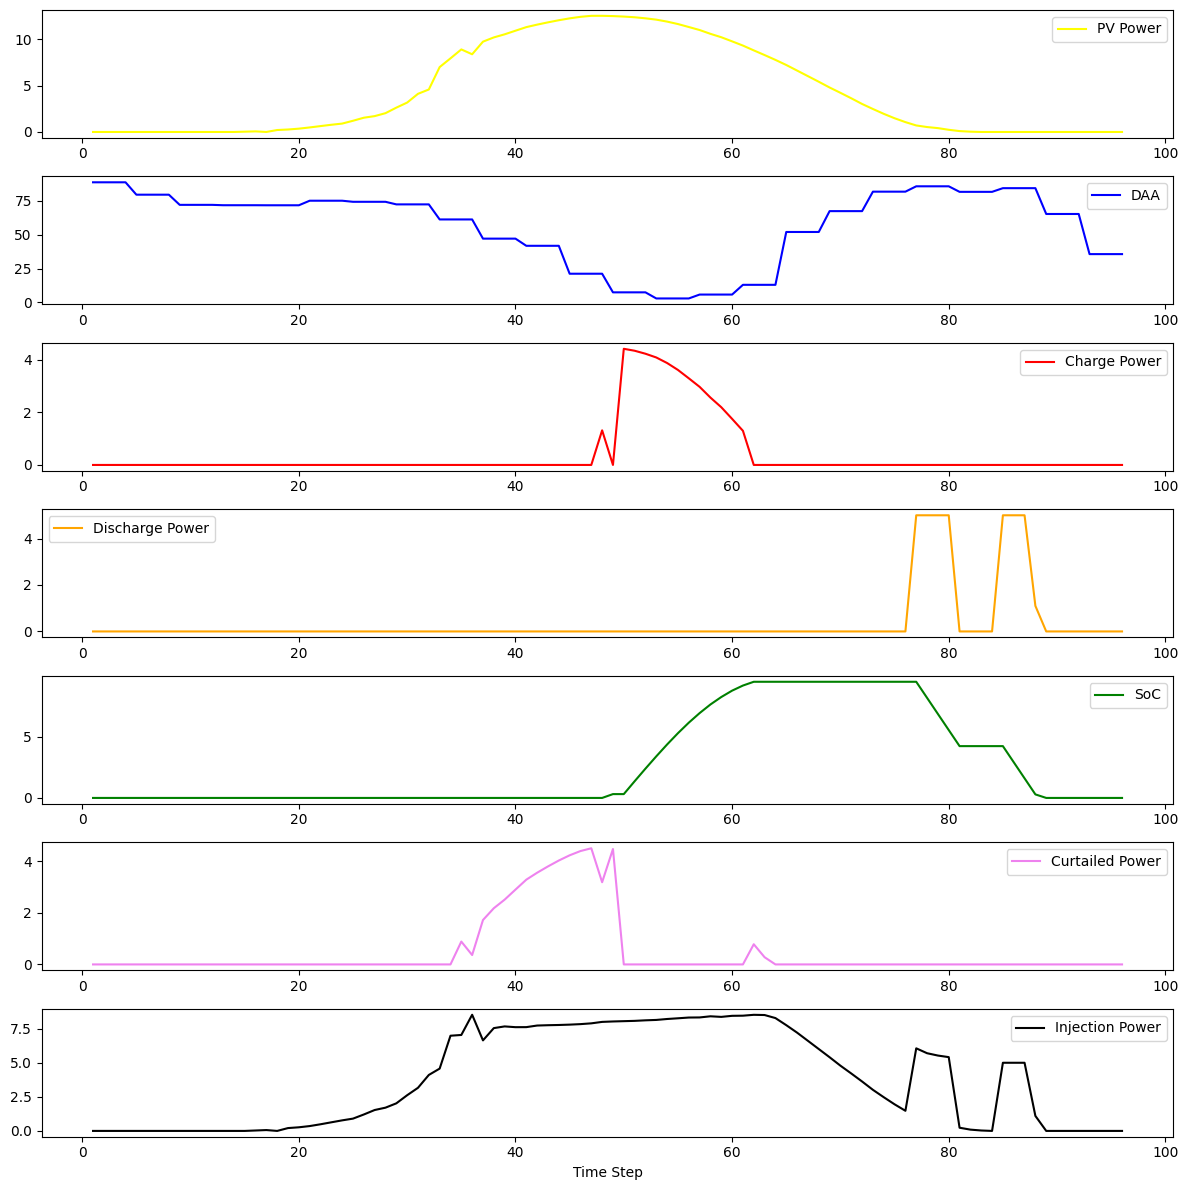

In [6]:
# Plotting the results
fig, ax = plt.subplots(7, 1, figsize=(12,12))

ax[0].plot(range(1, len(daa) + 1), pv_output, label='PV Power', color='yellow')
ax[1].plot(range(1, len(daa) + 1), daa, label='DAA', color='blue')
ax[2].plot(range(1, len(daa) + 1), p_charge, label='Charge Power', color='red')
ax[3].plot(range(1, len(daa) + 1), p_discharge, label='Discharge Power', color='orange')
ax[4].plot(range(1, len(daa) + 1), soc, label='SoC', color='green')
ax[5].plot(range(1, len(daa) + 1), p_curtailed, label='Curtailed Power', color='violet')
ax[6].plot(range(1, len(daa) + 1), injection_power, label='Injection Power', color='black')

ax[6].set_xlabel('Time Step')

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()
ax[4].legend()
ax[5].legend()
ax[6].legend()

plt.tight_layout()
# plt.show()
plt.savefig('results.png')